In [171]:
import os, re, math, random
from pathlib import Path

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [172]:
# -------------------------
# MASK DATASET PATHS
# -------------------------
PAIRS_DIR  = Path("/zpool/vladlab/data_drive/geogaze_data/pairs")

MASK_SIDE = "R"   # "L" or "R"
MASKS_DIR = Path("/zpool/vladlab/data_drive/geogaze_data/left_masks" if MASK_SIDE == "L"
                 else "/zpool/vladlab/data_drive/geogaze_data/right_masks")

OUTPUT_DIR = Path("/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/identification")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# CORNET REPO + ITEM PRESENCE CKPT (EDIT THESE)
# -------------------------
CORN_NET_REPO = Path("/zpool/vladlab/active_drive/omaltz/git_repos/CORnet")  # your local clone
CKPT_PATH = Path("/zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_scripts/cornet_z_identification_model_big_200/20260116_110503/best.pt")  # <-- CHANGE
NUM_CLASSES = 80 

# -------------------------
# TRAINING CONFIG
# -------------------------
PAIR_MIDS = ["gs_gc"] 

# NEW: single run folder for this model
MODEL_TAG = f"cornetIDEN_mask{MASK_SIDE}_{'-'.join(PAIR_MIDS)}"
RUN_DIR = OUTPUT_DIR / MODEL_TAG
RUN_DIR.mkdir(parents=True, exist_ok=True)
print("RUN_DIR:", RUN_DIR)

IMG_SIZE = 224

SEED = 345
EPOCHS = 200
BATCH_SIZE = 32
NUM_WORKERS = 8

VAL_SPLIT = 0.2
LR = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4
STEP_SIZE = 10

THRESHOLD = 0.2
POS_WEIGHT = 10 
USE_AMP = (DEVICE.type == "cuda")

print("MASK_SIDE:", MASK_SIDE)
print("PAIR_MIDS:", PAIR_MIDS)
print("CKPT_PATH:", CKPT_PATH)


RUN_DIR: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/identification/cornetIDEN_maskR_gs_gc
MASK_SIDE: R
PAIR_MIDS: ['gs_gc']
CKPT_PATH: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_scripts/cornet_z_identification_model_big_200/20260116_110503/best.pt


In [173]:
def set_seed(s):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

set_seed(SEED)


In [174]:
allowed_mids = [m.strip() for m in PAIR_MIDS if m.strip()]
mid_union = "|".join(re.escape(m) for m in allowed_mids)
PAIR_RE = re.compile(rf"^pair_({mid_union})_(\d+)\.png$")

def mask_path(side, mid, id_):
    p = MASKS_DIR / f"mask{side}_{mid}_{id_}.png"
    return p if p.is_file() else None

def collect_items(side):
    items, skipped = [], 0
    for fn in os.listdir(PAIRS_DIR):
        m = PAIR_RE.match(fn)
        if not m:
            continue
        mid, id_ = m.group(1), m.group(2)
        img_p = PAIRS_DIR / fn
        msk_p = mask_path(side, mid, id_)
        if msk_p is None:
            skipped += 1
            continue
        items.append((img_p, msk_p, mid, id_))
    items.sort(key=lambda x: (x[2], int(x[3])))
    if skipped:
        print(f"[WARN] Skipped {skipped} image(s) with no matching mask{side}.")
    print(f"[INFO] Found {len(items)} (image, mask{side}) pairs across MIDs: {allowed_mids}")
    return items

all_items = collect_items(MASK_SIDE)
assert len(all_items) > 0, "No (image, mask) pairs found."
print("Example item:", all_items[0])


[INFO] Found 500 (image, maskR) pairs across MIDs: ['gs_gc']
Example item: (PosixPath('/zpool/vladlab/data_drive/geogaze_data/pairs/pair_gs_gc_0011.png'), PosixPath('/zpool/vladlab/data_drive/geogaze_data/right_masks/maskR_gs_gc_0011.png'), 'gs_gc', '0011')


In [175]:
infer_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

def load_mask_binary(path: Path):
    """
    Returns mask as float tensor shape (1,H,W) with values in {0,1}.

    IMPORTANT:
    This matches your earlier segmentation script:
      foreground = 1 where pixel == 0 (black)

    If your foreground is white, change to: (m > 0)
    """
    m = np.asarray(Image.open(path).convert("L"), dtype=np.uint8)
    m = (m == 0).astype(np.float32)   # <-- flip if needed
    return torch.from_numpy(m).unsqueeze(0)

class PairMaskDataset(Dataset):
    def __init__(self, items, tfms):
        self.items = items
        self.tfms = tfms

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        img_p, msk_p, mid, id_ = self.items[i]
        img = Image.open(img_p).convert("RGB")
        x = self.tfms(img)            # (3,224,224)
        y = load_mask_binary(msk_p)   # (1,224,224)
        return x, y, f"{mid}_{id_}"

# Split train/val
rng = random.Random(SEED)
shuf = all_items[:]
rng.shuffle(shuf)
n_val = max(1, int(len(shuf) * VAL_SPLIT))
val_items = shuf[:n_val]
trn_items = shuf[n_val:]

print(f"[INFO] Train: {len(trn_items)} | Val: {len(val_items)}")

trainloader = DataLoader(PairMaskDataset(trn_items, infer_tfms),
                         batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=NUM_WORKERS, pin_memory=True)

valloader = DataLoader(PairMaskDataset(val_items, infer_tfms),
                       batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True)

# Sanity check a batch
xb, yb, ids = next(iter(trainloader))
print("x:", xb.shape, xb.dtype)
print("y:", yb.shape, yb.dtype, "unique:", torch.unique(yb))
print("ids[0]:", ids[0])


[INFO] Train: 400 | Val: 100
x: torch.Size([32, 3, 224, 224]) torch.float32
y: torch.Size([32, 1, 224, 224]) torch.float32 unique: tensor([0., 1.])
ids[0]: gs_gc_1967


In [176]:
import sys
sys.path.insert(0, str(CORN_NET_REPO))

import cornet
print("Imported cornet from:", cornet.__file__)


Imported cornet from: /zpool/vladlab/active_drive/omaltz/git_repos/CORnet/cornet/__init__.py


In [177]:
def replace_last_linear(model: nn.Module, out_features: int):
    last_name, last_linear = None, None
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            last_name, last_linear = name, module
    if last_linear is None:
        raise RuntimeError("No nn.Linear found in model.")

    parent = model
    parts = last_name.split(".")
    for p in parts[:-1]:
        parent = getattr(parent, p)

    setattr(parent, parts[-1], nn.Linear(last_linear.in_features, out_features))
    return model, last_linear.in_features, last_name

def get_state_dict_from_ckpt(ckpt_obj):
    if isinstance(ckpt_obj, dict) and "model_state" in ckpt_obj:
        return ckpt_obj["model_state"]
    if isinstance(ckpt_obj, dict) and "state_dict" in ckpt_obj:
        return ckpt_obj["state_dict"]
    return ckpt_obj

def strip_module_prefix(state_dict):
    # If keys start with "module.", strip it
    if not isinstance(state_dict, dict):
        return state_dict
    keys = list(state_dict.keys())
    if len(keys) > 0 and all(k.startswith("module.") for k in keys):
        return {k[len("module."):]: v for k, v in state_dict.items()}
    return state_dict

# Build CORnet-Z
corn = cornet.cornet_z(pretrained=False)
corn, in_features, last_name = replace_last_linear(corn, out_features=NUM_CLASSES)
print(f"Replaced {last_name} with Linear({in_features} -> {NUM_CLASSES})")

corn = corn.to(DEVICE)

# Load checkpoint
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
state = get_state_dict_from_ckpt(ckpt)
state = strip_module_prefix(state)

missing, unexpected = corn.load_state_dict(state, strict=False)
print("Loaded ckpt:", CKPT_PATH)
print("Missing keys:", len(missing))
print("Unexpected keys:", len(unexpected))

corn.eval()


Replaced module.decoder.linear with Linear(512 -> 80)
Loaded ckpt: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_scripts/cornet_z_identification_model_big_200/20260116_110503/best.pt
Missing keys: 10
Unexpected keys: 10


DataParallel(
  (module): Sequential(
    (V1): CORblock_Z(
      (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
      (nonlin): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (output): Identity()
    )
    (V2): CORblock_Z(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (nonlin): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (output): Identity()
    )
    (V4): CORblock_Z(
      (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (nonlin): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (output): Identity()
    )
    (IT): CORblock_Z(
      (conv): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (nonlin): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, strid

In [178]:
def cornet_it_features(model: nn.Module, x: torch.Tensor) -> torch.Tensor:
    """
    Runs CORnet-Z up through IT and returns the IT feature map (B, C, h, w).
    Works even if model is wrapped in DataParallel.
    """
    m = model.module if isinstance(model, nn.DataParallel) else model

    for name in ["V1", "V2", "V4", "IT"]:
        if not hasattr(m, name):
            raise AttributeError(
                f"CORnet model missing attribute '{name}'. "
                f"Available: {list(m._modules.keys())}"
            )

    x = m.V1(x)
    x = m.V2(x)
    x = m.V4(x)
    x = m.IT(x)
    return x

class CORnetITSeg(nn.Module):
    def __init__(self, cornet_model: nn.Module, it_channels: int):
        super().__init__()
        self.cornet = cornet_model
        self.proj = nn.Conv2d(it_channels, 1, kernel_size=1)

    def forward(self, x):
        feat = cornet_it_features(self.cornet, x)         # (B,C,h,w)
        logits = self.proj(feat)                          # (B,1,h,w)
        H, W = x.shape[-2:]
        logits = F.interpolate(logits, size=(H, W), mode="bilinear", align_corners=False)
        return logits

# Infer IT channel count
xb, yb, _ = next(iter(trainloader))
xb = xb.to(DEVICE)

with torch.no_grad():
    it_feat = cornet_it_features(corn, xb)
print("IT feature shape:", it_feat.shape)

it_channels = it_feat.shape[1]
model = CORnetITSeg(corn, it_channels=it_channels).to(DEVICE)

with torch.no_grad():
    out = model(xb)
print("Logits shape:", out.shape)


IT feature shape: torch.Size([32, 512, 7, 7])
Logits shape: torch.Size([32, 1, 224, 224])


In [179]:
def freeze_encoder(seg_model: CORnetITSeg):
    for p in seg_model.cornet.parameters():
        p.requires_grad = False
    seg_model.cornet.eval()

freeze_encoder(model)

# Init decoder to small foreground prior (5%)
nn.init.zeros_(model.proj.weight)
nn.init.constant_(model.proj.bias, math.log(0.05 / 0.95))

optimizer = torch.optim.SGD(model.proj.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE)

pos_weight_tensor = torch.tensor(POS_WEIGHT, device=DEVICE) if POS_WEIGHT > 0 else None
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

trainable = [n for n,p in model.named_parameters() if p.requires_grad]
print("Trainable params:", trainable)


Trainable params: ['proj.weight', 'proj.bias']


/tmp/ipykernel_3878016/3279400340.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


In [180]:
def dice_coef(pred_bin, target, eps=1e-6):
    inter = (pred_bin * target).sum(dim=(1,2,3))
    union = pred_bin.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    return ((2*inter + eps) / (union + eps)).mean()

def iou_coef(pred_bin, target, eps=1e-6):
    inter = (pred_bin * target).sum(dim=(1,2,3))
    union = pred_bin.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - inter
    return ((inter + eps) / (union + eps)).mean()


In [181]:
best_dice = -1e9
tag = MODEL_TAG  # reuse the run name from Cell 1
save_path = RUN_DIR / f"{tag}_best.pth"
save_path.parent.mkdir(parents=True, exist_ok=True)  # safety


print("Saving best to:", save_path)
print("Starting training...")

for epoch in range(1, EPOCHS + 1):
    # ---- Train ----
    model.train()
    model.cornet.eval()  # keep encoder frozen + BN stats fixed
    train_loss_sum, n_train = 0.0, 0

    for imgs, masks, _ in trainloader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(imgs)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss_sum += loss.item() * imgs.size(0)
        n_train += imgs.size(0)

    scheduler.step()
    train_loss = train_loss_sum / max(1, n_train)

    # ---- Validate ----
    model.eval()
    val_loss_sum, n_val = 0.0, 0
    dices, ious = [], []

    with torch.no_grad():
        for imgs, masks, _ in valloader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(imgs)
                loss = criterion(logits, masks)
                preds = (torch.sigmoid(logits) > THRESHOLD).float()

            val_loss_sum += loss.item() * imgs.size(0)
            n_val += imgs.size(0)
            dices.append(dice_coef(preds, masks).item())
            ious.append(iou_coef(preds, masks).item())

    val_loss = val_loss_sum / max(1, n_val)
    mean_dice = float(np.mean(dices)) if dices else 0.0
    mean_iou  = float(np.mean(ious))  if ious else 0.0

    print(f"Epoch {epoch:03d} | Train {train_loss:.6f} | Val {val_loss:.6f} | Dice {mean_dice:.3f} | IoU {mean_iou:.3f}")

    # ---- Save best ----
    if mean_dice > best_dice:
        best_dice = mean_dice
        torch.save({
            "epoch": epoch,
            "best_dice": best_dice,
            "mask_side": MASK_SIDE,
            "pair_mids": PAIR_MIDS,
            "threshold": THRESHOLD,
            "pos_weight": POS_WEIGHT,
            "state_dict": model.state_dict(),
            "presence_ckpt_loaded_from": str(CKPT_PATH),
        }, save_path)
        print(f"  [BEST] Saved new best Dice={best_dice:.3f} -> {save_path}")


Saving best to: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/identification/cornetIDEN_maskR_gs_gc/cornetIDEN_maskR_gs_gc_best.pth
Starting training...


/tmp/ipykernel_3878016/1289975364.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 001 | Train 0.330185 | Val 0.309681 | Dice 0.000 | IoU 0.000
  [BEST] Saved new best Dice=0.000 -> /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/identification/cornetIDEN_maskR_gs_gc/cornetIDEN_maskR_gs_gc_best.pth


/tmp/ipykernel_3878016/1289975364.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 002 | Train 0.300564 | Val 0.296410 | Dice 0.010 | IoU 0.006
  [BEST] Saved new best Dice=0.010 -> /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/identification/cornetIDEN_maskR_gs_gc/cornetIDEN_maskR_gs_gc_best.pth
Epoch 003 | Train 0.293784 | Val 0.290832 | Dice 0.081 | IoU 0.047
  [BEST] Saved new best Dice=0.081 -> /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/identification/cornetIDEN_maskR_gs_gc/cornetIDEN_maskR_gs_gc_best.pth
Epoch 004 | Train 0.287031 | Val 0.284531 | Dice 0.002 | IoU 0.001
Epoch 005 | Train 0.281194 | Val 0.279171 | Dice 0.027 | IoU 0.019
Epoch 006 | Train 0.275728 | Val 0.273914 | Dice 0.117 | IoU 0.071
  [BEST] Saved new best Dice=0.117 -> /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/identification/cornetIDEN_maskR_gs_gc/cornetIDEN_maskR_gs_gc_best.pth
Epoch 007 | Train 0.270464 | Val 0.268891 | Dice 0.255 | IoU 0.159
  [BEST] Saved new best Dice=0.255 -> /zpool/vladlab/active_drive/omaltz/scripts/g

Loaded: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/identification/cornetIDEN_maskR_gs_gc/cornetIDEN_maskR_gs_gc_best.pth
Missing keys: 0 | Unexpected keys: 0
Found 32 image(s) in /zpool/vladlab/active_drive/omaltz/scripts/geogaze/decoder_model/stimuli/out/test_stimuli/test_pairs


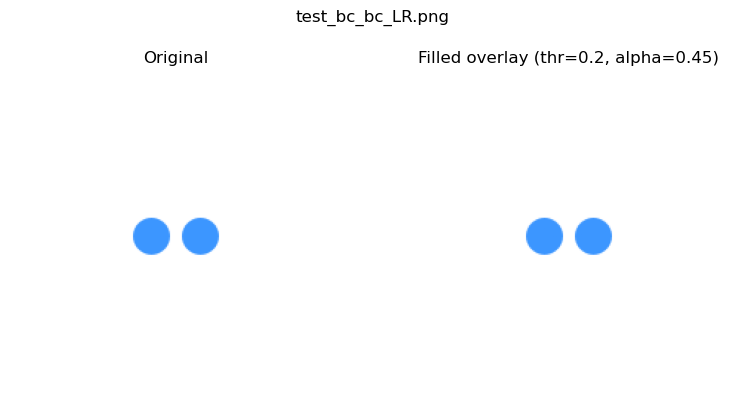

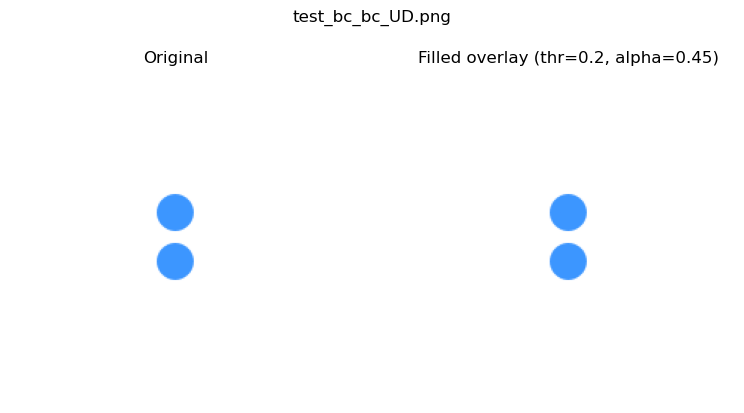

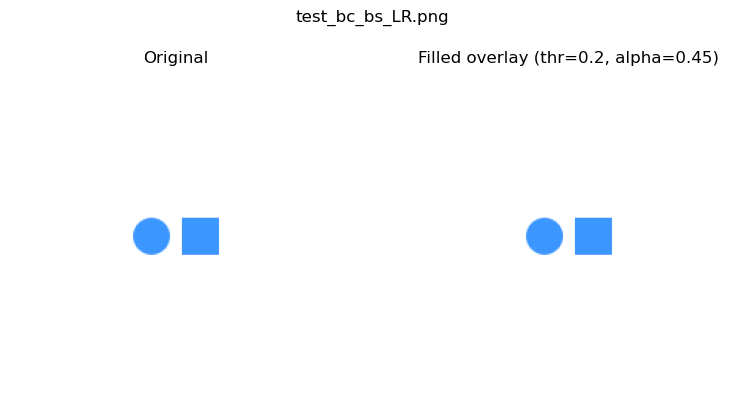

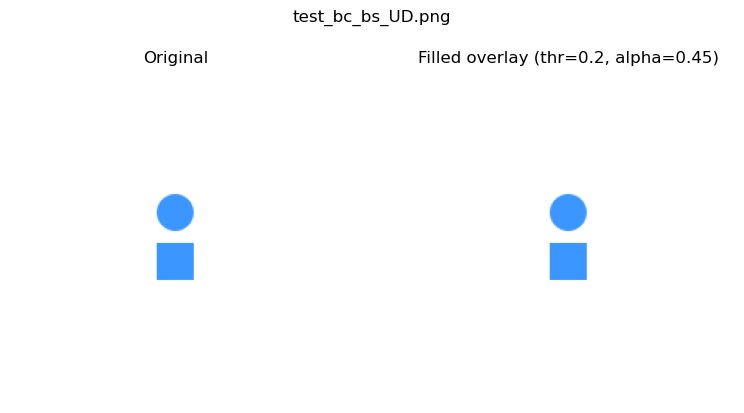

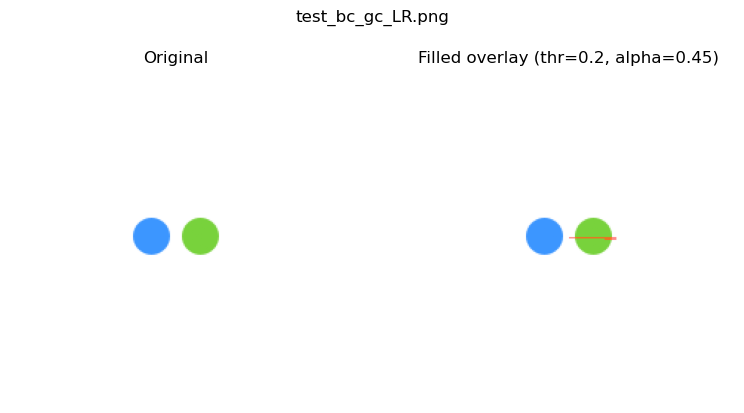

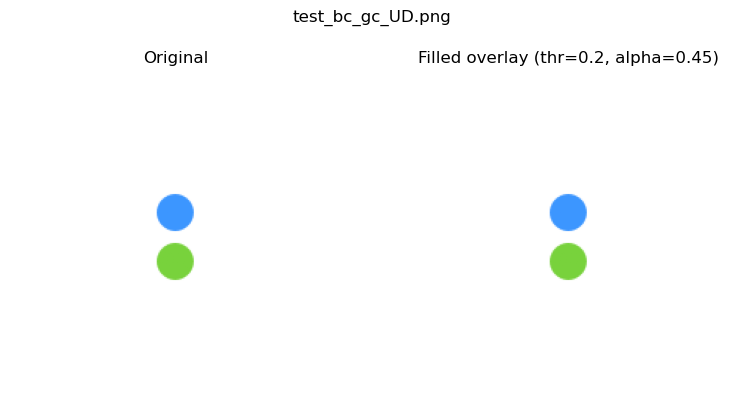

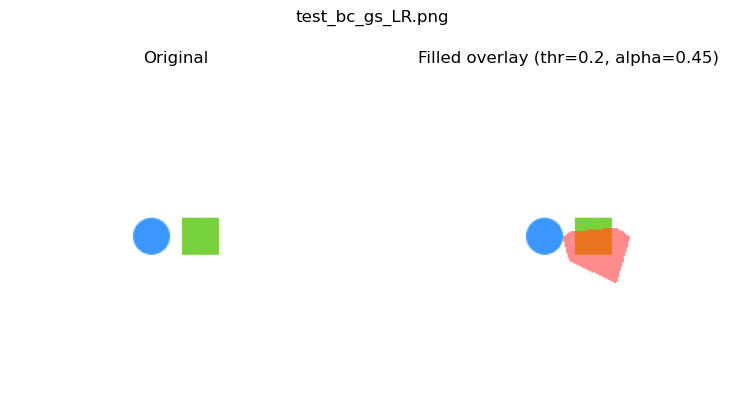

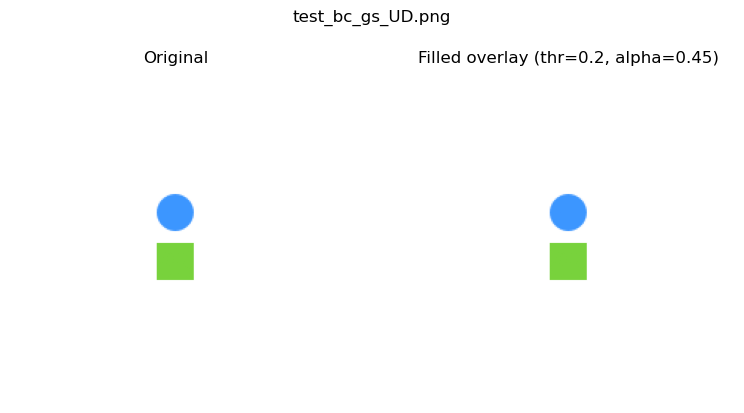

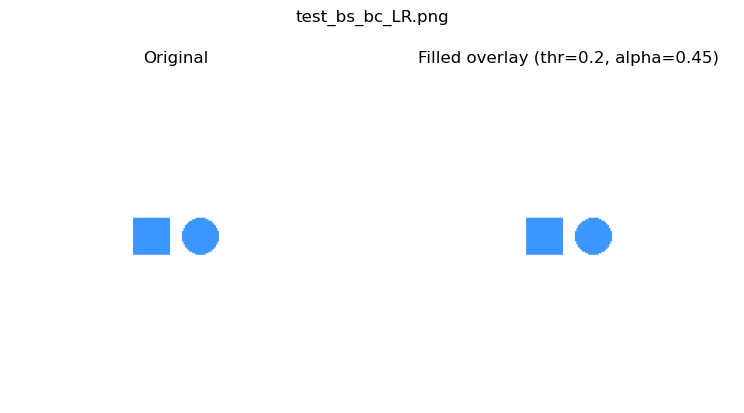

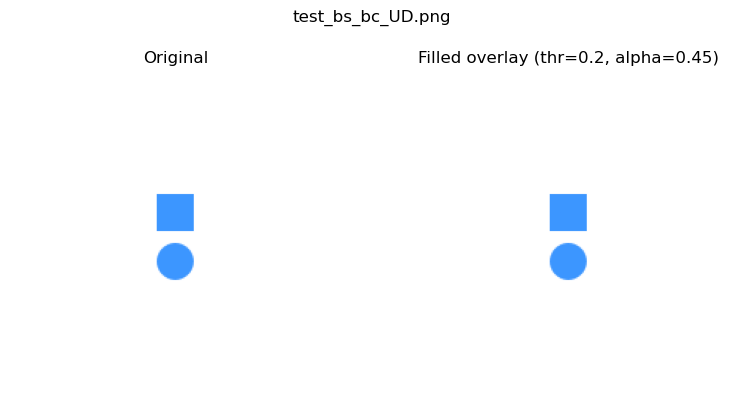

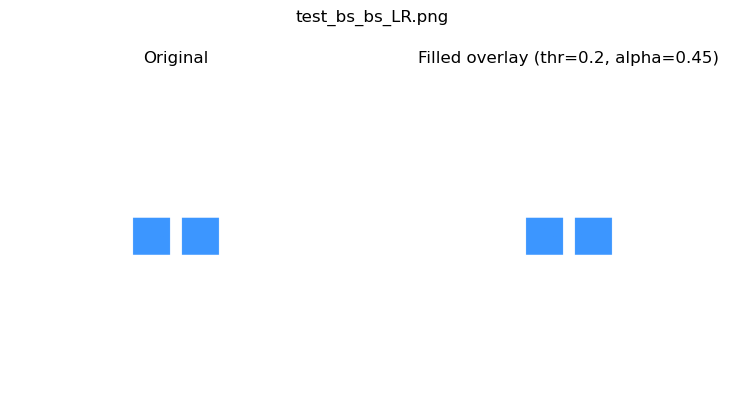

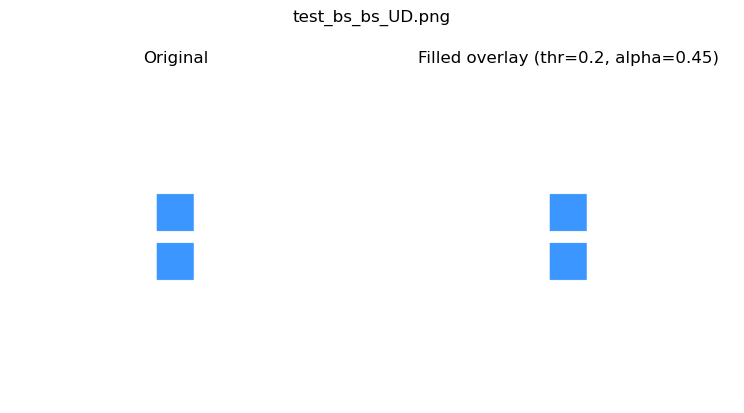

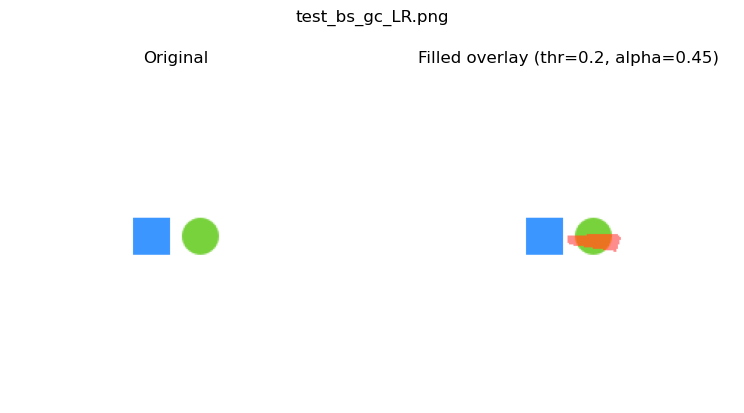

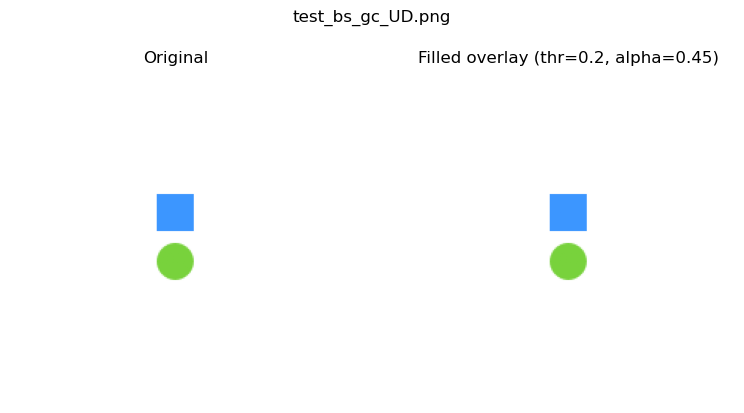

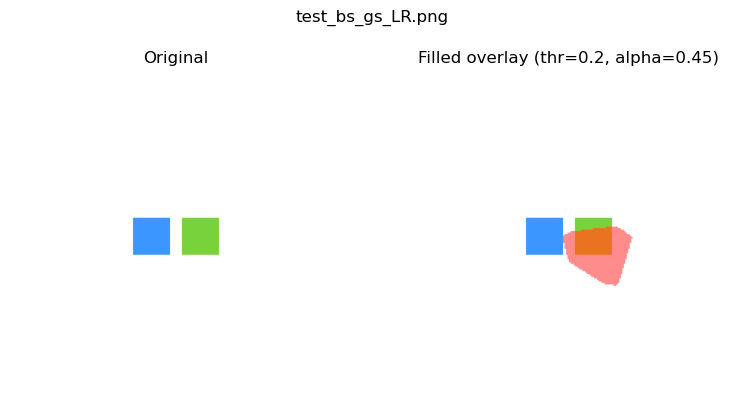

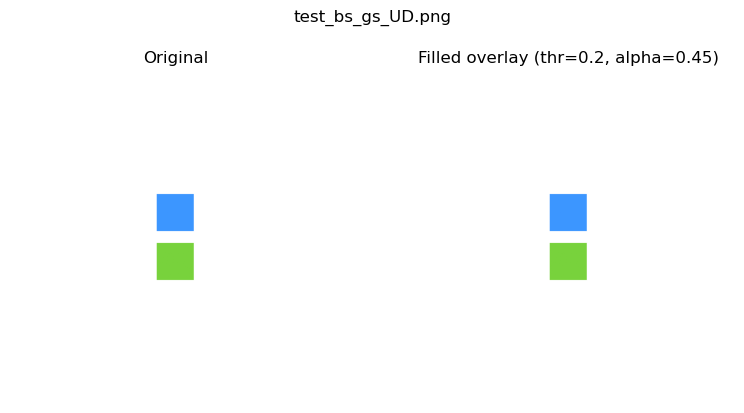

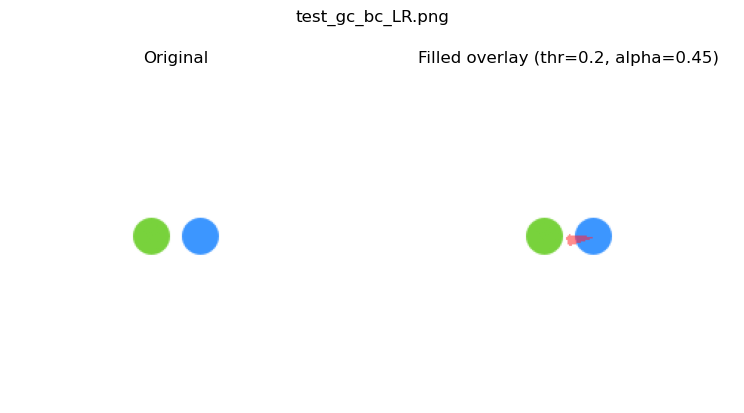

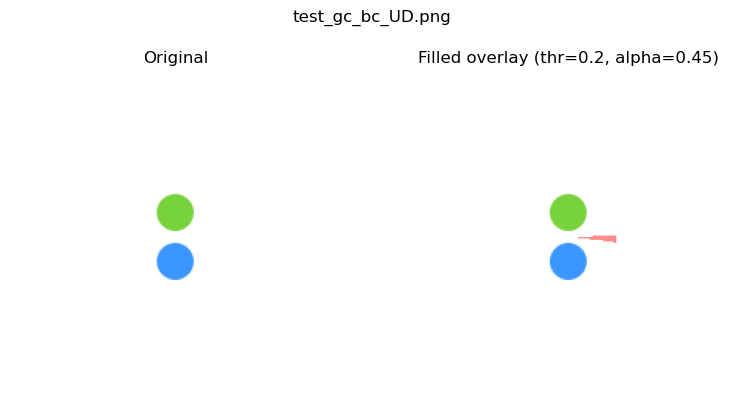

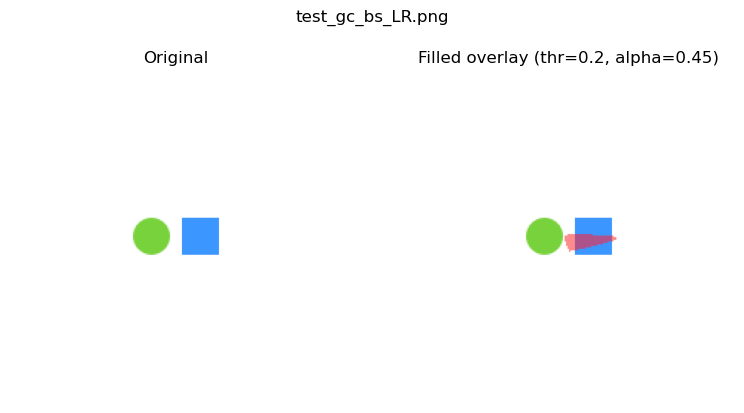

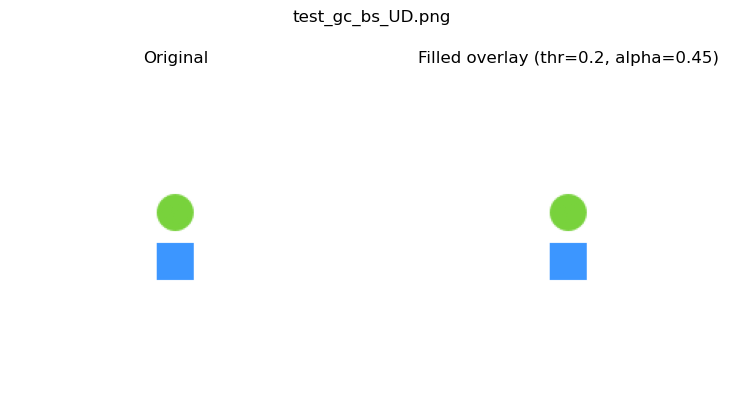

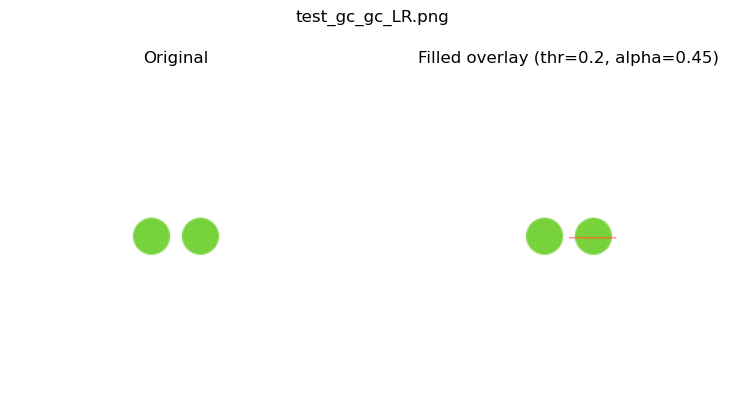

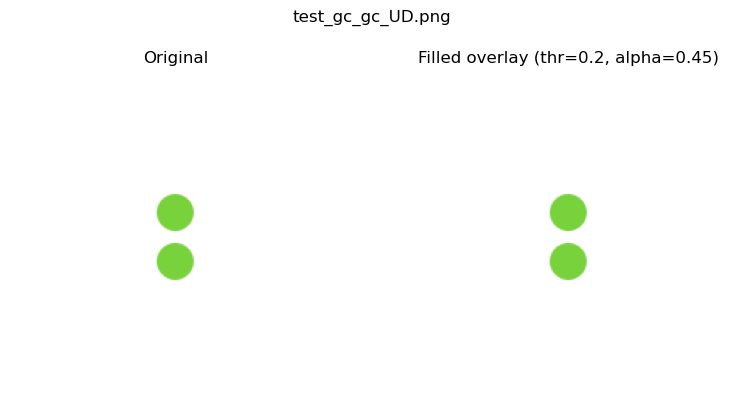

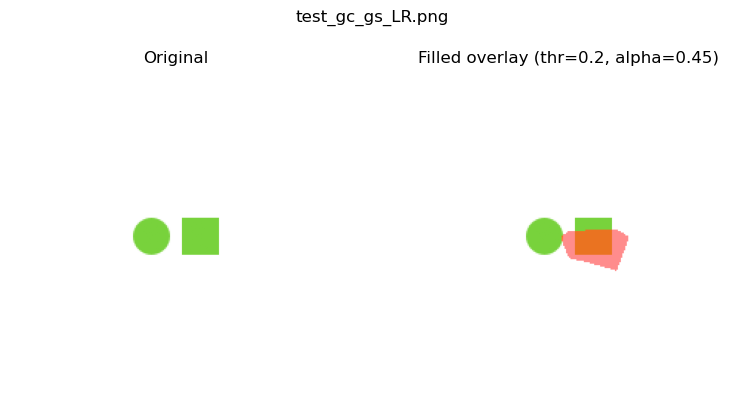

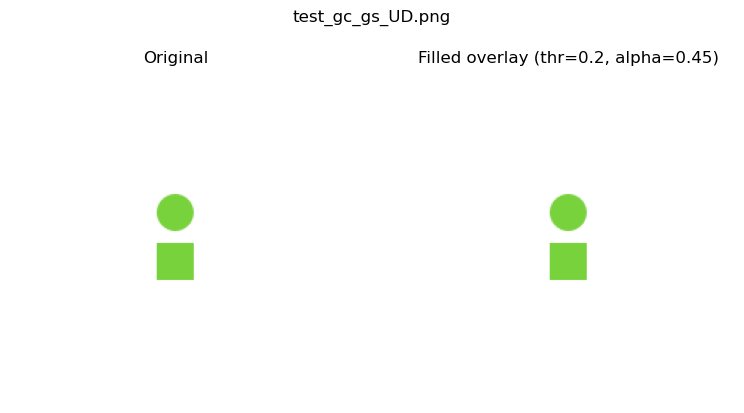

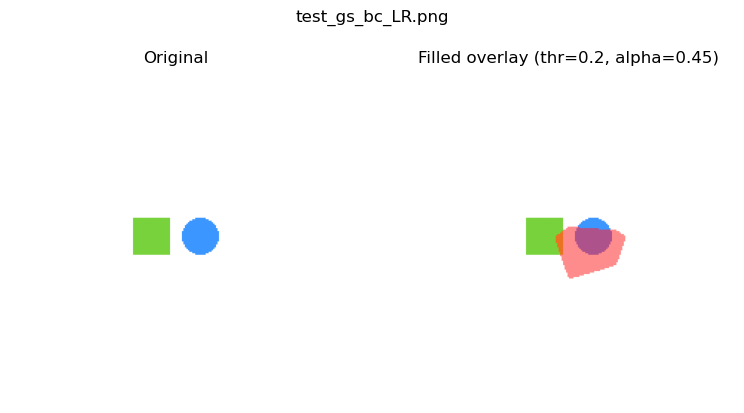

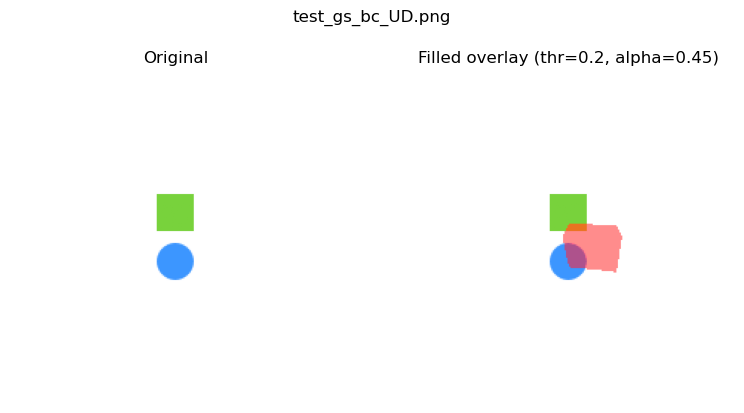

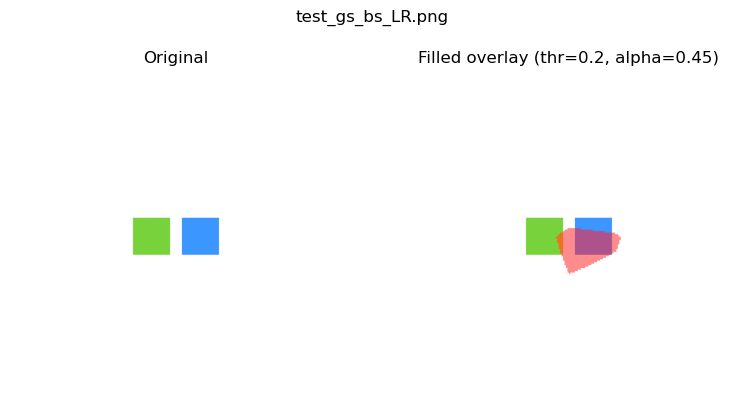

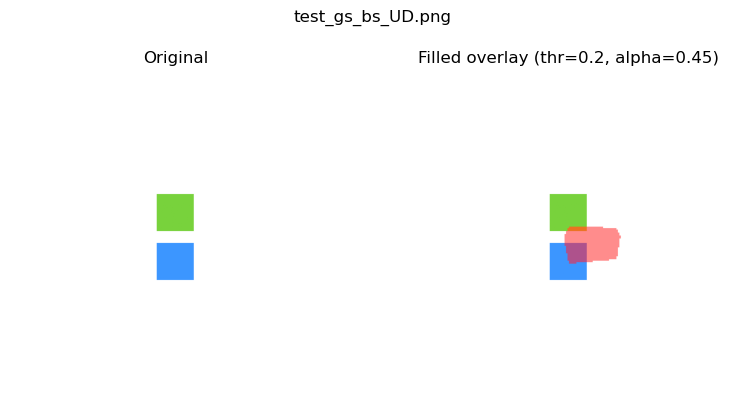

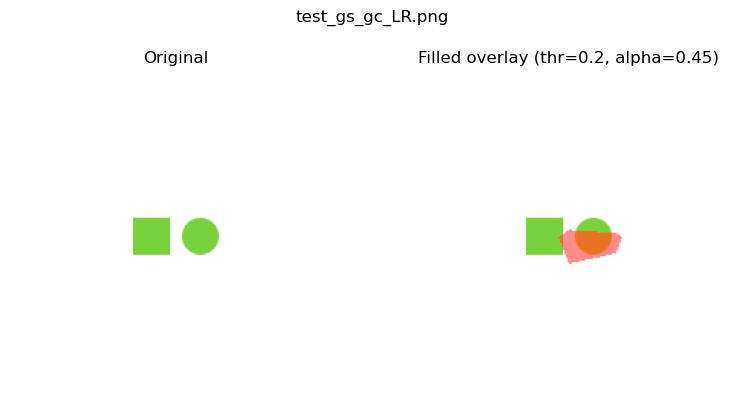

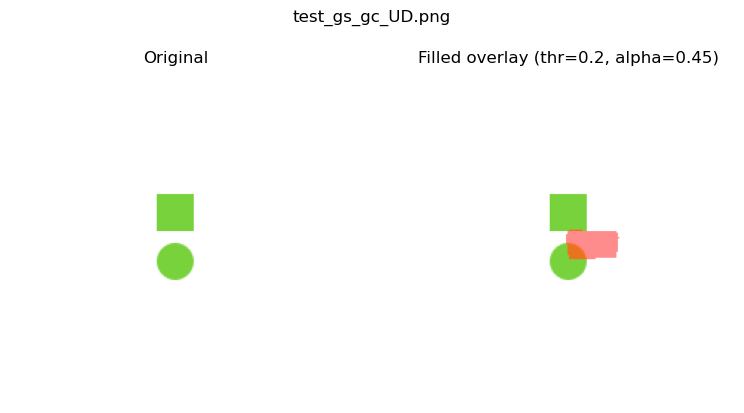

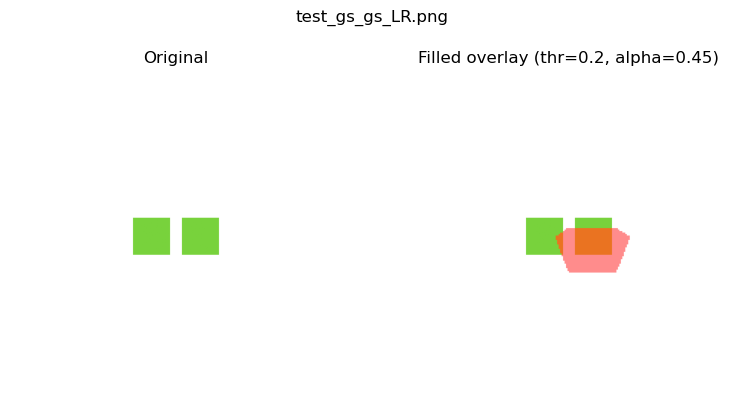

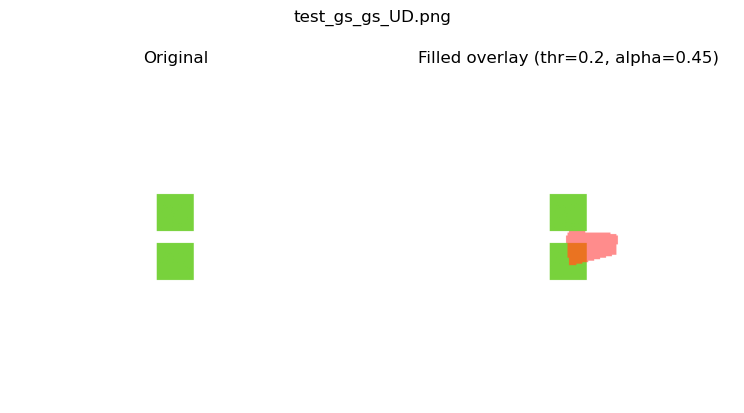

Done. Overlays saved to: /zpool/vladlab/active_drive/omaltz/scripts/geogaze/coco_decoder/identification/cornetIDEN_maskR_gs_gc/cornetIDEN_maskR_gs_gc_overlays


In [182]:
# Cell — Run a folder of images through the ITEM-DETECTION CORnet-Z + IT-decoder model + filled overlay

import os
from pathlib import Path
import numpy as np
from PIL import Image
import torch
import matplotlib.pyplot as plt
import torchvision.transforms as T

# ----------------------------
# paths
# ----------------------------
INFER_DIR = Path("/zpool/vladlab/active_drive/omaltz/scripts/geogaze/decoder_model/stimuli/out/test_stimuli/test_pairs") 
BEST_CKPT = save_path  # (or: RUN_DIR / f"{MODEL_TAG}_best.pth")

MASK_DIR = RUN_DIR / f"{MODEL_TAG}_masks"
OVERLAY_DIR = RUN_DIR / f"{MODEL_TAG}_overlays"
MASK_DIR.mkdir(parents=True, exist_ok=True)
OVERLAY_DIR.mkdir(parents=True, exist_ok=True)

VIEW_THRESHOLD = THRESHOLD   # keep consistent with training; feel free to set e.g. 0.3 for visualization
ALPHA = 0.45                 # overlay transparency
SAVE_PNGS = True             # set False if you only want plots

# ----------------------------
# Helpers
# ----------------------------
exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

infer_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),  # images already 224x224, but safe
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

def denorm_img(x):
    """x: (3,224,224) normalized tensor -> (224,224,3) float numpy in [0,1]"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    y = (x.cpu() * std) + mean
    y = torch.clamp(y, 0, 1)
    return y.permute(1,2,0).numpy()

def overlay_filled_mask(rgb_img_01, mask_01, alpha=0.45):
    """
    rgb_img_01: (H,W,3) in [0,1]
    mask_01: (H,W) in {0,1} or [0,1]
    returns overlay image (H,W,3) in [0,1]
    """
    mask_01 = np.clip(mask_01, 0, 1)
    overlay = rgb_img_01.copy()
    # red overlay where mask is present
    overlay[..., 0] = np.clip(overlay[..., 0] + alpha * mask_01, 0, 1)
    overlay[..., 1] = np.clip(overlay[..., 1] * (1 - alpha * mask_01), 0, 1)
    overlay[..., 2] = np.clip(overlay[..., 2] * (1 - alpha * mask_01), 0, 1)
    return overlay

# ----------------------------
# Load best checkpoint into your existing model
# ----------------------------
ckpt = torch.load(BEST_CKPT, map_location=DEVICE)

if "model" not in globals():
    raise RuntimeError(
        "I don't see `model` in memory. Run the earlier cells that build the CORnetITSeg model first "
        "(the cells where you print IT feature shape and logits shape)."
    )

state = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt
missing, unexpected = model.load_state_dict(state, strict=False)
print("Loaded:", BEST_CKPT)
print("Missing keys:", len(missing), "| Unexpected keys:", len(unexpected))

model.eval()

# ----------------------------
# Collect images
# ----------------------------
paths = sorted([p for p in INFER_DIR.iterdir() if p.is_file() and p.suffix.lower() in exts])
if len(paths) == 0:
    raise ValueError(f"No images found in: {INFER_DIR} (looked for {sorted(exts)})")
print(f"Found {len(paths)} image(s) in {INFER_DIR}")

# ----------------------------
# Run inference + plot overlays
# ----------------------------
for p in paths:
    pil = Image.open(p).convert("RGB")
    x = infer_tfms(pil).unsqueeze(0).to(DEVICE)  # (1,3,224,224)

    with torch.no_grad():
        logits = model(x)  # (1,1,224,224)
        probs = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()  # (224,224)
        pred = (probs > VIEW_THRESHOLD).astype(np.float32)          # (224,224)

    rgb = denorm_img(x[0])  # (224,224,3)
    overlay = overlay_filled_mask(rgb, pred, alpha=ALPHA)

    # Plot
    plt.figure(figsize=(8, 4))
    plt.suptitle(p.name, y=1.02)

    ax1 = plt.subplot(1, 2, 1)
    ax1.imshow(rgb)
    ax1.set_title("Original")
    ax1.axis("off")

    ax2 = plt.subplot(1, 2, 2)
    ax2.imshow(overlay)
    ax2.set_title(f"Filled overlay (thr={VIEW_THRESHOLD}, alpha={ALPHA})")
    ax2.axis("off")

    plt.tight_layout()
    plt.show()

    if SAVE_PNGS:
        # Save raw mask (0/255)
        mask_path = MASK_DIR / f"{p.stem}_mask.png"
        Image.fromarray((pred.astype(np.uint8) * 255)).save(mask_path)

        # Save overlay
        overlay_path = OVERLAY_DIR / f"{p.stem}_overlay.png"
        Image.fromarray((overlay * 255).astype(np.uint8)).save(overlay_path)


print("Done. Overlays saved to:", OVERLAY_DIR)
